# TUTORIAL: lightcurve inference with NMMA

This notebook is a step-by-step guide for lightcurve inference using **NMMA**
1) Open the data
2) Instantiate a light curve model
3) Define the priors
4) Setup the systematics and likelihood
5) Inference & Post-processing

In [1]:
import pathlib

import bilby
import matplotlib.pyplot as plt
import numpy as np

## 1. Open the data

For this tutorial, we will use real data from AT2017gfo, the kilonova associated to GW170817. 

In [2]:
from nmma.em.io import load_em_observations

parent_dir = pathlib.Path().parent.resolve()
parent_dir = pathlib.Path(parent_dir).parent.resolve()

# Load the AT2017gfo data from the example data directory
photometry_data = load_em_observations(
    filename=f"{parent_dir}/example_files/lightcurves/AT2017gfo_corrected.dat"
)

# returns a dictionary with each filter as a key and a dictionnary containing the time, magnitude, and error as values
photometry_data

/home/liteul/Fahren_retreat/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.



Install m4opt if you want to use uvex filters


/home/liteul/Fahren_retreat/.venv/lib/python3.12/site-packages/ligo/skymap/io/events/ligolw.py:26: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
I0000 00:00:1789571933.852883   60563 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789571938.844316   60563 po

Install gaussian-process-api if you want to use it...


{'2massh': {'time': array([57983.   , 57983.758, 57983.969, 57984.761, 57984.969, 57985.776,
         57985.974, 57986.71 , 57986.974, 57990.   , 57991.   , 57992.   ]),
  'mag': array([18.205, 17.585, 17.585, 17.465, 17.585, 17.515, 17.665, 17.715,
         17.965, 18.685, 19.205, 19.605]),
  'mag_error': array([0.15, 0.04, 0.08, 0.04, 0.08, 0.04, 0.07, 0.04, 0.1 , 0.06, 0.26,
         0.14])},
 '2massj': {'time': array([57983.   , 57983.758, 57983.969, 57984.761, 57984.969, 57985.776,
         57985.974, 57986.71 , 57986.974, 57988.99 , 57990.   , 57991.   ,
         57992.   ]),
  'mag': array([17.793, 17.423, 17.493, 17.603, 17.643, 17.693, 17.863, 18.043,
         18.083, 18.653, 19.173, 19.553, 20.143]),
  'mag_error': array([0.03, 0.03, 0.07, 0.04, 0.09, 0.05, 0.07, 0.12, 0.07, 0.04, 0.28,
         0.11, 0.1 ])},
 '2massks': {'time': array([57983.   , 57983.758, 57983.969, 57984.761, 57984.969, 57985.776,
         57985.974, 57986.71 , 57986.974, 57988.99 , 57990.   , 57991.   ,

After importing the data, we must convert it into the right format for inference, this step will also allow us to define the trigger time of the event.

In [3]:
from nmma.em.utils import setup_filtered_lc_data

# we choose a trigger time of 57982.75, which is 0.25 days before the time of the 1st detection in our data
lc_data = setup_filtered_lc_data(photometry_data, trigger_time=57982.75)

We will now plot our lightcurve for an easier visualization.

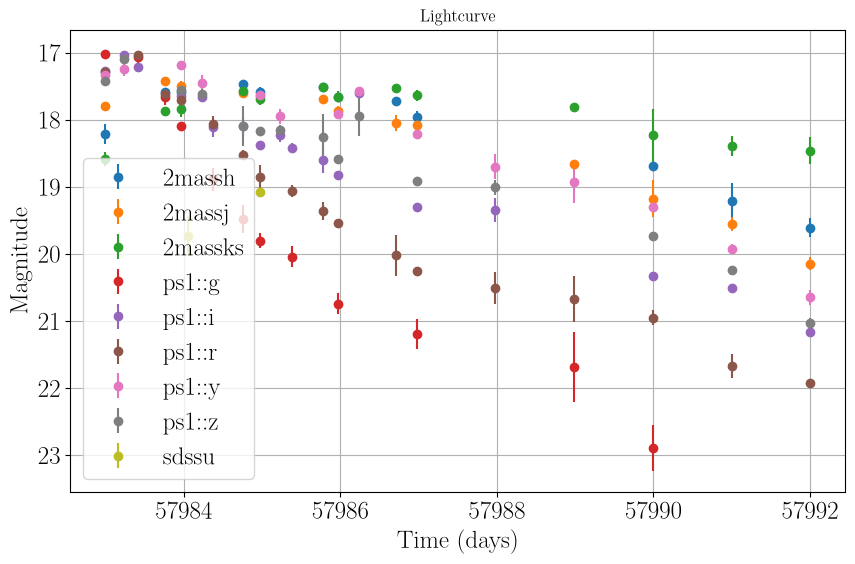

In [4]:
%matplotlib inline


def plot_lightcurve(photometry_data):
    """
    Plots the lightcurve data from the photometry_data dictionary.

    Parameters:
    photometry_data (dict): A dictionary containing lightcurve data for different filters.
    """
    plt.figure(figsize=(10, 6))

    for filter_name, data in photometry_data.items():
        time = np.array(data["time"])
        magnitude = np.array(data["mag"])
        error = np.array(data["mag_error"])

        plt.errorbar(time, magnitude, yerr=error, fmt="o", label=filter_name)

    plt.gca().invert_yaxis()  # Invert y-axis for magnitudes
    # plt.yscale('log')  # Set y-axis to logarithmic scale
    plt.xlabel("Time (days)")
    plt.ylabel("Magnitude")
    plt.title("Lightcurve")
    plt.legend()
    plt.grid(axis="both")
    plt.show()


plot_lightcurve(photometry_data)

## 2. Loading the model

For this tutorial, we will use the `Bu2026_MLP` surrogate model from `fiestaEM`, which is natively included in `nmma`. As different models have different parameters, you will need to adapt your priors to the specific model you are using.

In [5]:
from nmma.em.model import FiestaKilonovaModel

# Define the filters used in the lightcurve data
filters = list(photometry_data.keys())

# initialize the FiestaKilonovaModel with the specified model and filters
fiesta_model = FiestaKilonovaModel(model="Bu2026_MLP", filters=filters)

17:18 fiesta INFO    : Loading surrogate Bu2026_MLP. This surrogate should only be used in the following parameter ranges:
17:18 fiesta INFO    : 	 log10_mej_dyn: (-4.0, -1.3010299956639813)
17:18 fiesta INFO    : 	 v_ej_dyn: (0.12, 0.35)
17:18 fiesta INFO    : 	 Ye_dyn: (0.15, 0.35)
17:18 fiesta INFO    : 	 log10_mej_wind: (-4.0, -0.5502131530142267)
17:18 fiesta INFO    : 	 v_ej_wind: (0.05, 0.15)
17:18 fiesta INFO    : 	 Ye_wind: (0.2, 0.4)
17:18 fiesta INFO    : 	 inclination_EM: (0.0, 1.5707963267948966)
17:18 fiesta INFO    : Surrogate Bu2026_MLP is loading with source-frame time range [ 0.19405578 27.52765949] days.
17:18 fiesta INFO    : Surrogate Bu2026_MLP is loading with the following filters: ['2massh', '2massj', '2massks', 'ps1::g', 'ps1::i', 'ps1::r', 'ps1::y', 'ps1::z', 'sdssu'].
17:19 fiesta INFO    : Loaded for surrogate Bu2026_MLP from /home/liteul/Fahren_retreat/.venv/lib/python3.12/site-packages/fiesta/surrogates/KN/Bu2026_MLP/model.


## 3. Define the priors
NMMA uses bilby to run the sampler, hence the priors are defined as simple bilby `PriorDict` object.

`Bu2026_MLP` has 8 parameters:
- `log10_mej_dyn` : The mass of the dynamical ejecta ($\log_{10} M_{\odot}$)
- `v_ej_dyn`: The velocity of the dynamical ejecta as a fraction of C
- `Ye_dyn`: The electron fraction of the dynamical ejecta
- `log10_mej_wind` : The mass of the wind ejecta ($\log_{10} M_{\odot}$)
- `v_ej_wind`: The velocity of the wind ejecta as a fraction of C
- `Ye_wind`: The electron fraction of the wind ejecta
- `inclination_EM`: Inclination of the source (in rad)

We will also add 2 additional parameters that are common to all models:
- `luminosity_distance`: The luminosity distance in Mpc
- `timeshift`: The delay between the true $t_0$ of the event and the chosen trigger time

In [6]:
priors = bilby.core.prior.PriorDict()

priors["log10_mej_dyn"] = bilby.core.prior.Uniform(
    -4, -1.3010299956639813, "log10_mej_dyn", latex_label=r"$\log_{10} M_{ej}^{dyn}$"
)
priors["v_ej_dyn"] = bilby.core.prior.Uniform(
    0.12, 0.35, "v_ej_dyn", latex_label=r"$v_{ej}^{dyn}$"
)
priors["Ye_dyn"] = bilby.core.prior.Uniform(
    0.15, 0.35, "Ye_dyn", latex_label=r"$Y_e^{dyn}$"
)
priors["log10_mej_wind"] = bilby.core.prior.Uniform(
    -4, -0.5502131530142267, "log10_mej_wind", latex_label=r"$\log_{10} M_{ej}^{wind}$"
)
priors["v_ej_wind"] = bilby.core.prior.Uniform(
    0.05, 0.15, "v_ej_wind", latex_label=r"$v_{ej}^{wind}$"
)
priors["Ye_wind"] = bilby.core.prior.Uniform(
    0.2, 0.4, "Ye_wind", latex_label=r"$Y_e^{wind}$"
)
priors["inclination_EM"] = bilby.core.prior.Uniform(
    0, np.pi / 2, "inclination_EM", latex_label=r"$\iota$"
)
priors["luminosity_distance"] = bilby.core.prior.Uniform(
    1, 200, "luminosity_distance", latex_label=r"$D_L$"
)
priors["timeshift"] = bilby.core.prior.Uniform(
    -2, 0, "timeshift", latex_label=r"$\Delta t_0$"
)

print(priors)

{'log10_mej_dyn': Uniform(minimum=-4, maximum=-1.3010299956639813, name='log10_mej_dyn', latex_label='$\\log_{10} M_{ej}^{dyn}$', unit=None, boundary=None), 'v_ej_dyn': Uniform(minimum=0.12, maximum=0.35, name='v_ej_dyn', latex_label='$v_{ej}^{dyn}$', unit=None, boundary=None), 'Ye_dyn': Uniform(minimum=0.15, maximum=0.35, name='Ye_dyn', latex_label='$Y_e^{dyn}$', unit=None, boundary=None), 'log10_mej_wind': Uniform(minimum=-4, maximum=-0.5502131530142267, name='log10_mej_wind', latex_label='$\\log_{10} M_{ej}^{wind}$', unit=None, boundary=None), 'v_ej_wind': Uniform(minimum=0.05, maximum=0.15, name='v_ej_wind', latex_label='$v_{ej}^{wind}$', unit=None, boundary=None), 'Ye_wind': Uniform(minimum=0.2, maximum=0.4, name='Ye_wind', latex_label='$Y_e^{wind}$', unit=None, boundary=None), 'inclination_EM': Uniform(minimum=0, maximum=1.5707963267948966, name='inclination_EM', latex_label='$\\iota$', unit=None, boundary=None), 'luminosity_distance': Uniform(minimum=1, maximum=200, name='lumino

Once our priors are defined, we must check the time consistency of our model-prior-data setup. This ensures that the source frame model is still within the time domain covered by the model.

In [7]:
from nmma.em.utils import check_model_time_consistency

# check model time consistency
lc_data = check_model_time_consistency(lc_data, fiesta_model, priors)

## 4. Setup the sytematics and the likelihood

Due to intrinsic systematics associated to kilonova light curve models, we must add a additional error budget. 

In [8]:
from nmma.em.systematics import FilterSystematicsHandler

# initialize the FilterSystematicsHandler
systematics_handler = FilterSystematicsHandler(
    filters,  # filters
    None,  # systematic file -> We don't have one, so we set it to None
    1,  # error budget in magnitudes
    lc_data[0],  # lc times
)

Now, we have all we need to initialize our likelihood

In [9]:
from nmma.em.em_likelihood import EMTransientLikelihood

likelihood = EMTransientLikelihood(
    light_curve_model=fiesta_model,
    light_curve_data=lc_data,
    priors=priors,
    filters=filters,
    systematics_handler=systematics_handler,
    verbose=0,  # set to 0 to suppress output, set to 1 for more detailed output (warning: this will lightly increase the runtime of the likelihood evaluation)
)

## 5. Run the sampler and visualize the output

NMMA uses bilby's `run_sampler` function and supports multiple samplers:
```
bilby_mcmc', 'cpnest', 'dnest4', 'dynamic_dynesty', 'dynesty', 'emcee', 'fake_sampler', 'kombine', 'nessai', 'nestle', 'ptemcee', 'ptmcmcsampler', 'pymc', 'pymultinest', 'pypolychord', 'ultranest', 'zeus'
```
It should be noted that all samplers are not installed by default. 

For this tutorial we will use `dynesty`.

In [10]:
from bilby.core.sampler import run_sampler

from nmma.core.base import check_priors_and_likelihood_for_nmma

# check that the priors and likelihood are compatible
check_priors_and_likelihood_for_nmma(priors, likelihood)

# run the sampler
res = run_sampler(
    likelihood=likelihood,  # likelihood object
    priors=priors,  # prior dictionary
    sampler="dynesty",  # sampler to use
    nlive=512,  # number of live points (we use 32 for speed but for a real analysis you should use 1024 or more)
    seed=1234,  # random seed for reproducibility
    # npool=8,                    # number of cores to use (-1 means use all available cores)
    outdir="inference_results",  # output directory
    label="AT2017gfo",  # label for the run
    check_point_delta_t=3600,  # time in seconds between checkpoints (we use 1 hour here)
    save=0,
)

17:19 bilby INFO    : Running for label 'AT2017gfo', output will be saved to 'inference_results'
17:19 bilby INFO    : Analysis priors:
17:19 bilby INFO    : log10_mej_dyn=Uniform(minimum=-4, maximum=-1.3010299956639813, name='log10_mej_dyn', latex_label='$\\log_{10} M_{ej}^{dyn}$', unit=None, boundary=None)
17:19 bilby INFO    : v_ej_dyn=Uniform(minimum=0.12, maximum=0.35, name='v_ej_dyn', latex_label='$v_{ej}^{dyn}$', unit=None, boundary=None)
17:19 bilby INFO    : Ye_dyn=Uniform(minimum=0.15, maximum=0.35, name='Ye_dyn', latex_label='$Y_e^{dyn}$', unit=None, boundary=None)
17:19 bilby INFO    : log10_mej_wind=Uniform(minimum=-4, maximum=-0.5502131530142267, name='log10_mej_wind', latex_label='$\\log_{10} M_{ej}^{wind}$', unit=None, boundary=None)
17:19 bilby INFO    : v_ej_wind=Uniform(minimum=0.05, maximum=0.15, name='v_ej_wind', latex_label='$v_{ej}^{wind}$', unit=None, boundary=None)
17:19 bilby INFO    : Ye_wind=Uniform(minimum=0.2, maximum=0.4, name='Ye_wind', latex_label='$Y_e

Now that our analysis is done, we can produce additional figures, like a corner plot.

17:19 bilby INFO    : No extension given, defaulting to JSON.


17:19 bilby INFO    : Writing samples file to /home/liteul/Fahren_retreat/nmma/tutorials/inference_results/AT2017gfo_posterior_samples.dat


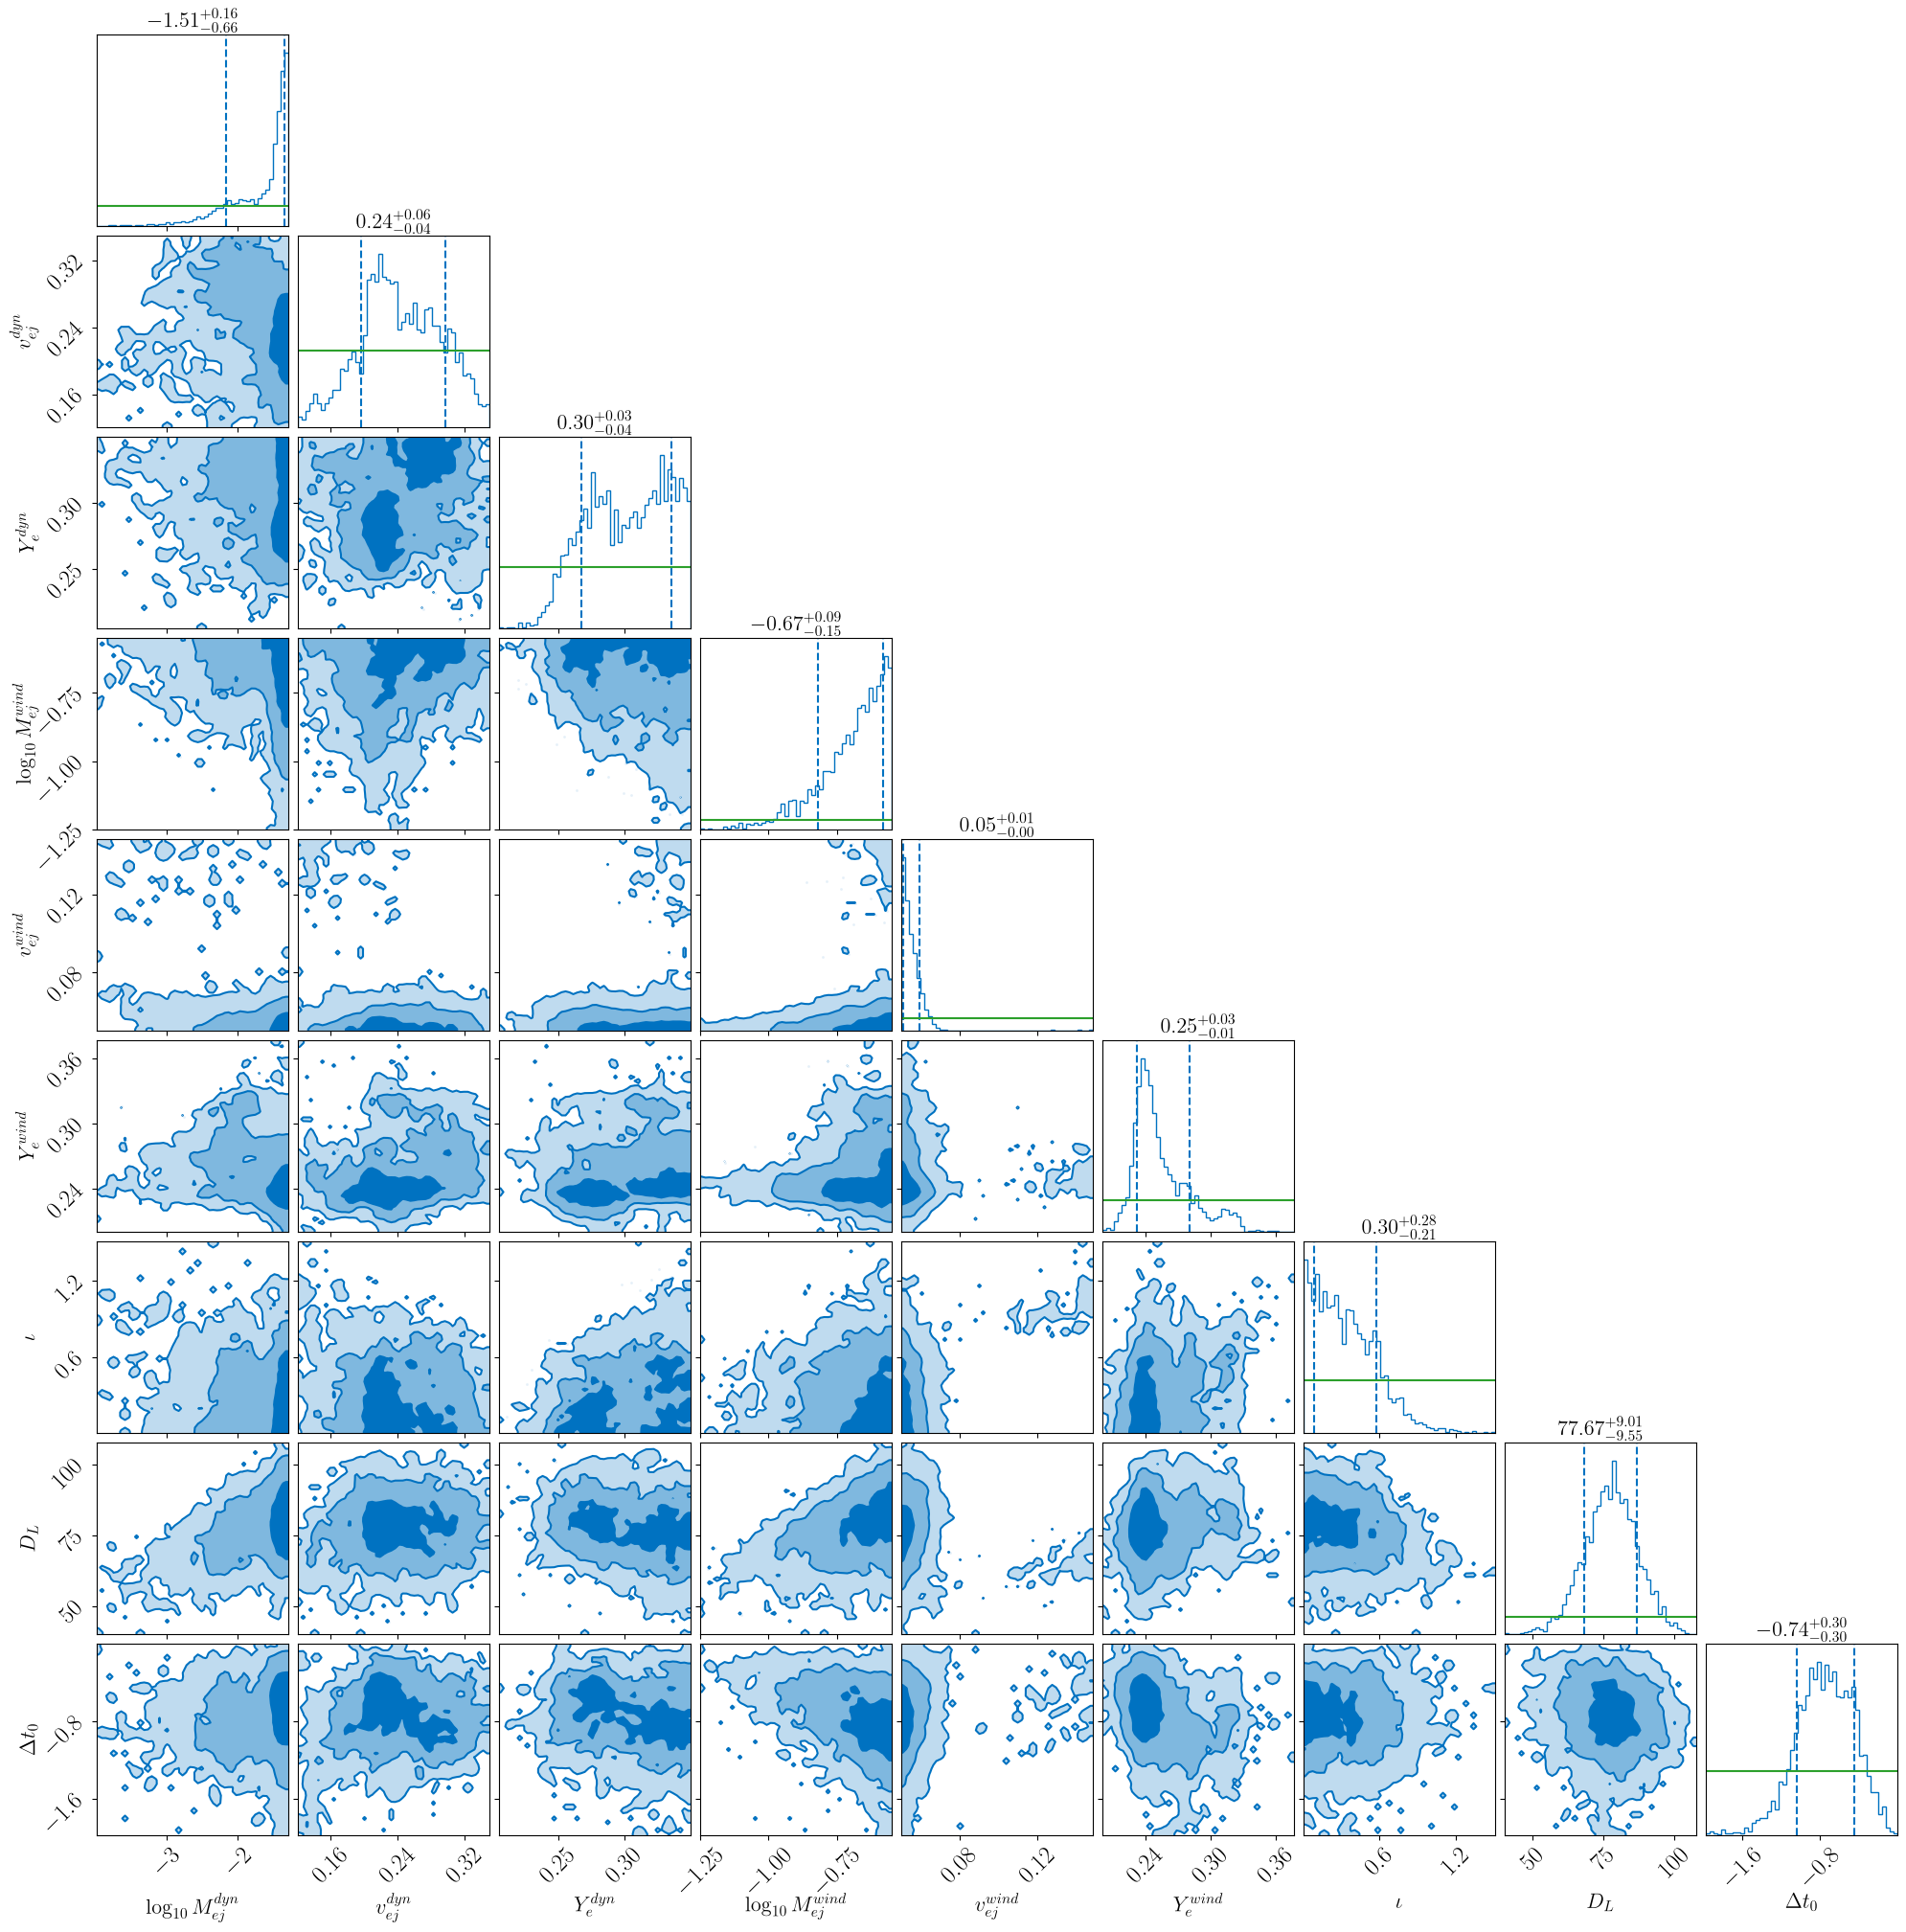

In [11]:
# save the posterior samples and results to file
res.posterior = likelihood.posterior_conversion(res.posterior)
res.save_to_file()
res.save_posterior_samples()

# produce a corner plot of the posterior samples
res.plot_corner(
    None, priors
)  # None means that we don't plot the injected values in the corner plot as we used real data

We can also plot the best-fit model with our data but this need a bit of post-processing

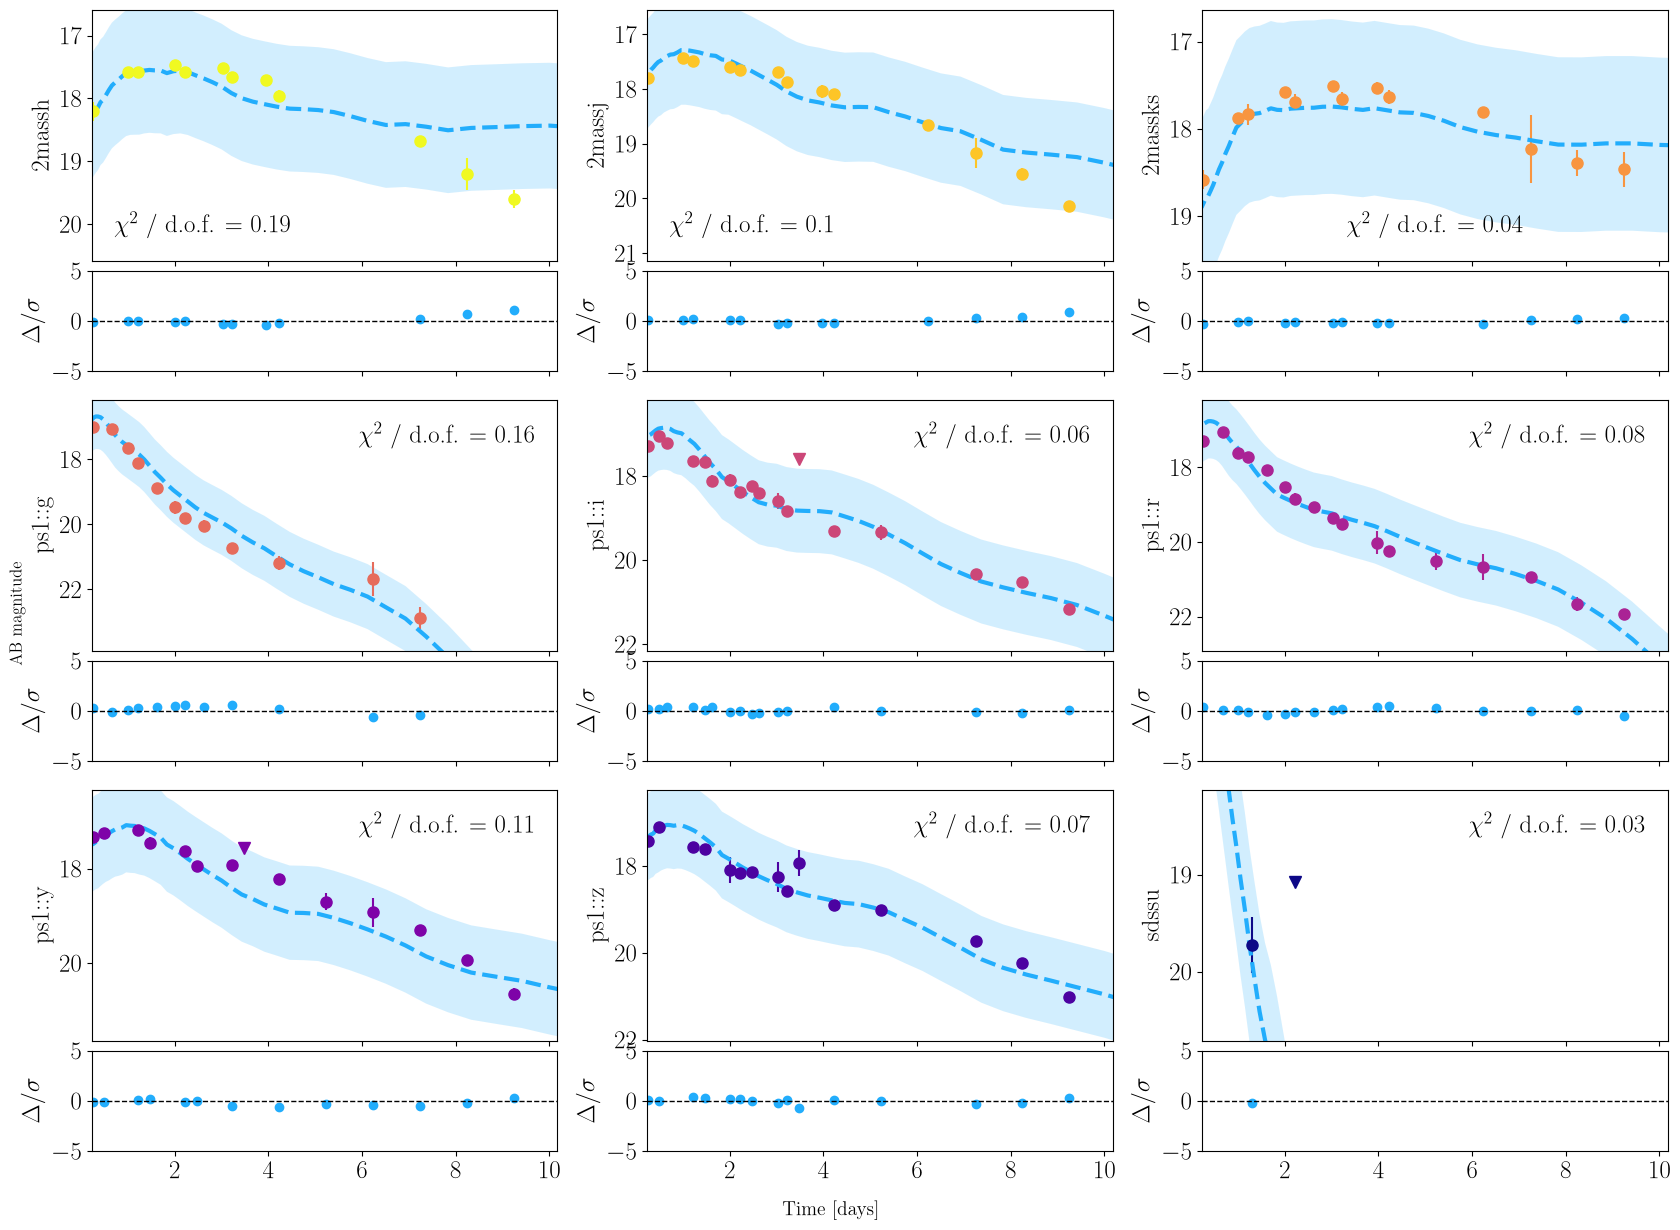

In [12]:
from nmma.em import utils
from nmma.em.lightcurve_handling import compute_chisquare_dict
from nmma.em.plotting_utils import basic_em_analysis_plot

transient = likelihood.sub_model  # the model object used in the likelihood

# Get the best-fit parameters from the posterior samples
bestfit = res.posterior.loc[res.posterior["log_likelihood"].idxmax()].to_dict()

# Parameter conversion to the model's parameter space
bestfit = likelihood.parameter_conversion(bestfit)

# Model light curves for the best-fit parameters
observable_times, best_mags = transient.light_curve_model.gen_detector_lc(bestfit)

# Systematic error handling for the best-fit model
model_error_data = transient.systematics_handler(bestfit)

model_error = {
    filt: utils.autocomplete_data(
        observable_times,
        transient.light_curve_times[filt],
        error,
        extrapolate="constant",
    )
    for filt, error in model_error_data.items()
}

# Restrain to the filters that have data to plot
plot_filters = {
    filt: filt
    for filt in transient.observed_filters
    if not np.isnan(transient.light_curves[filt]).all()
}

mags_to_plot = {filt: best_mags[filt] for filt in plot_filters}
mags_to_plot["time"] = observable_times

plot_error = {filt: model_error[filt] for filt in plot_filters}

# Compute statistics for the best-fit model
chi2_dict, mismatches = compute_chisquare_dict(
    transient,
    best_mags,
    observable_times,
    model_error,
    verbose=False,
)

# Plot
fig = basic_em_analysis_plot(
    transient=transient,
    plot_filters=plot_filters,
    mags_to_plot=mags_to_plot,
    error_dict=plot_error,
    chi2_dict=chi2_dict,
    mismatches=mismatches,
    sub_model_plot_props=None,
    xlim=None,
    ylim=None,
    save_path=pathlib.Path(res.outdir) / f"{res.label}_bestfit_lightcurves.png",
)